In [298]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import f_classif, SelectKBest



total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv", sep = ";")
total_data


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [299]:
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [300]:
total_data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [301]:
total_data.describe()



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [302]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [303]:
excluded_data = total_data.drop(["contact","month","day_of_week","duration", "campaign",
                            "pdays","previous",	"poutcome","emp.var.rate"], axis = 1, inplace= True)
print(excluded_data)


None


In [304]:
total_data


,age,job,marital,education,default,housing,loan,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,94.767,-50.8,1.028,4963.6,yes


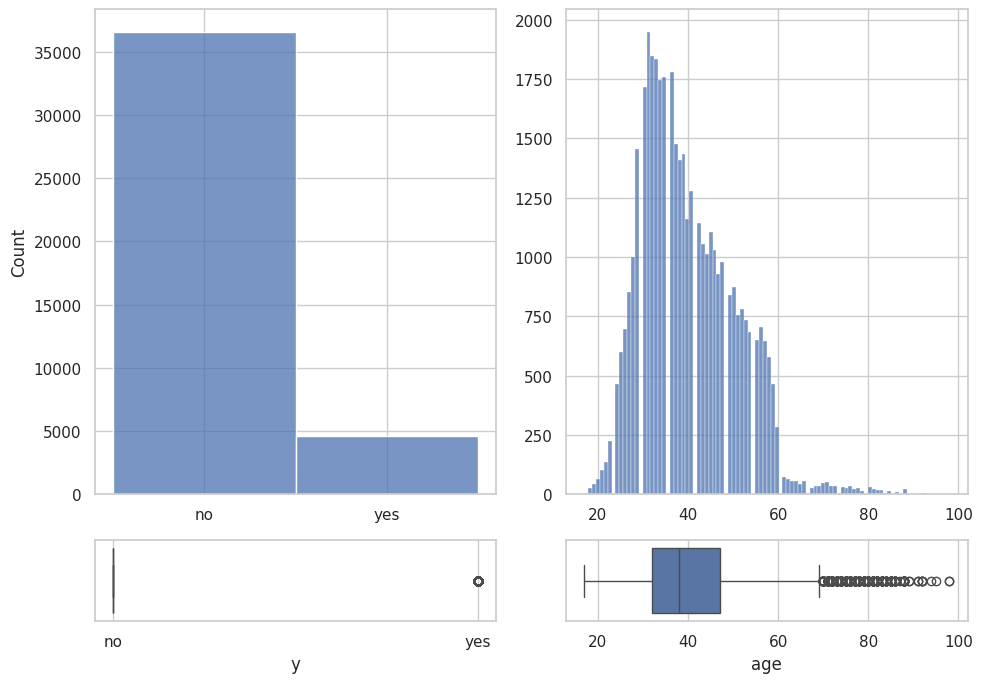

In [305]:
fig, axis = plt.subplots(2, 2, figsize = (10, 7), gridspec_kw={'height_ratios': [6, 1]})

# Creating a multiple figure with histograms and box plots
sns.histplot(ax = axis[0, 0], data = total_data, x = "y").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "y")
sns.histplot(ax = axis[0, 1], data = total_data, x = "age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "age")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

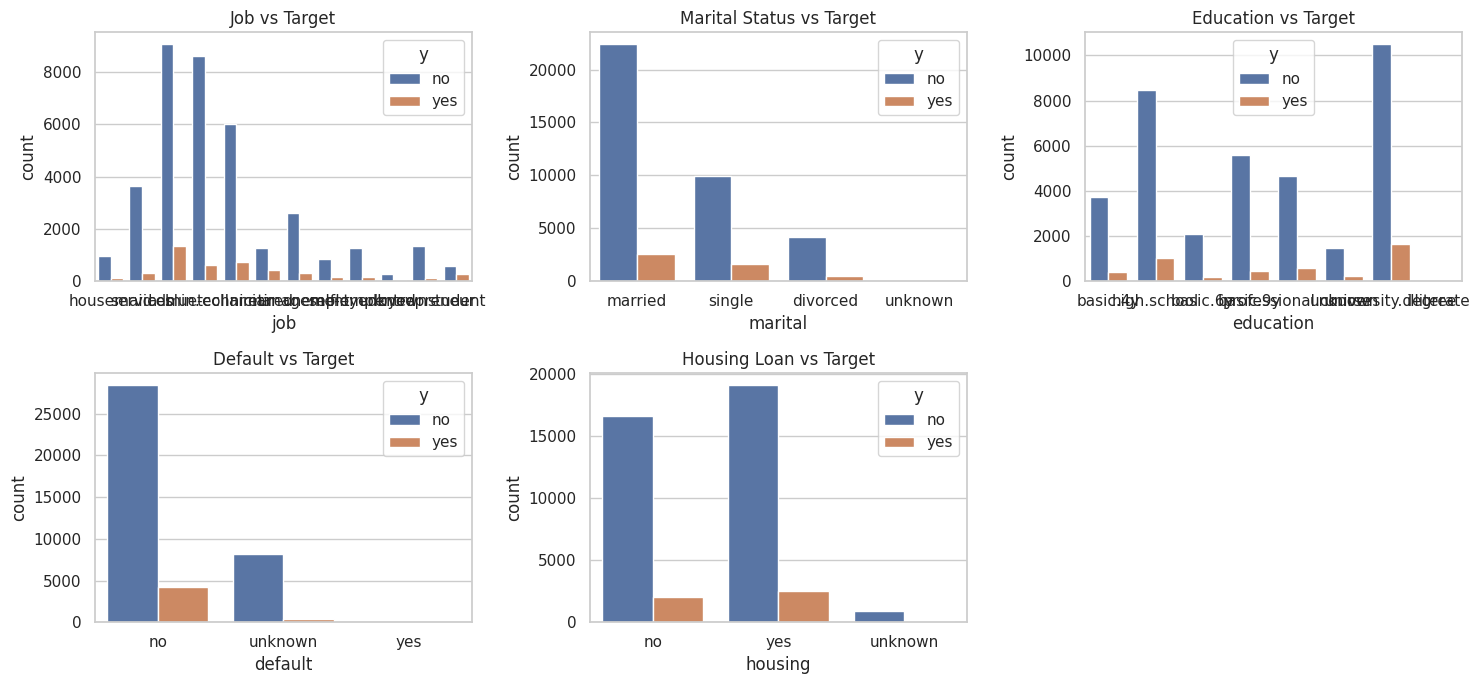

In [318]:


# Create subplots
fig, axis = plt.subplots(2, 3, figsize=(15, 7))

# Visualization 1: Job vs Target
sns.countplot(ax=axis[0, 0], data=total_data, x='job', hue='y').set_title('Job vs Target')

# Visualization 2: Marital Status vs Target
sns.countplot(ax=axis[0, 1], data=total_data, x='marital', hue='y').set_title('Marital Status vs Target')

# Visualization 3: Education vs Target
sns.countplot(ax=axis[0, 2], data=total_data, x='education', hue='y').set_title('Education vs Target')

# Visualization 4: Default vs Target
sns.countplot(ax=axis[1, 0], data=total_data, x='default', hue='y').set_title('Default vs Target')

# Visualization 5: Housing Loan vs Target
sns.countplot(ax=axis[1, 1], data=total_data, x='housing', hue='y').set_title('Housing Loan vs Target')

# Remove empty subplot (since we only have 5 plots)
plt.tight_layout()
fig.delaxes(axis[1, 2])

# Show the plot
plt.show()


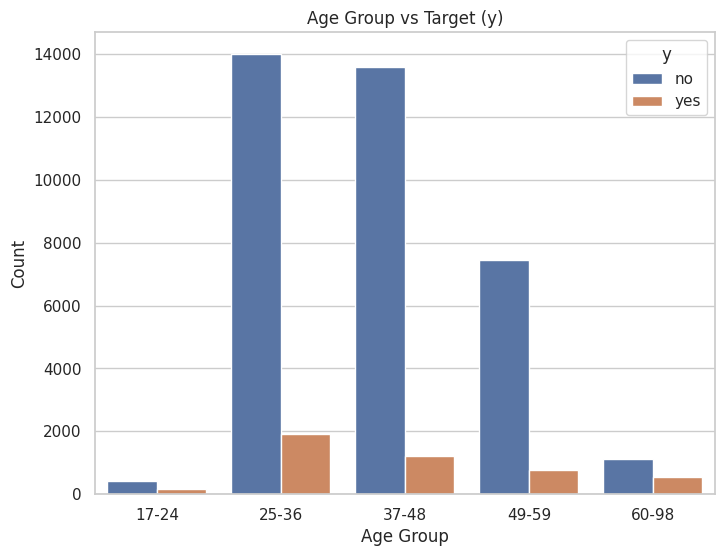

In [319]:
sns.set(style="whitegrid")


bins = [17, 24, 36, 48, 59, 98]
labels = ['17-24', '25-36', '37-48', '49-59', '60-98']


plt.figure(figsize=(8, 6))
sns.countplot(x=pd.cut(total_data['age'], bins=bins, labels=labels, right=False), hue='y', data=total_data)

plt.title('Age Group vs Target (y)')
plt.xlabel('Age Group')
plt.ylabel('Count')


plt.show()

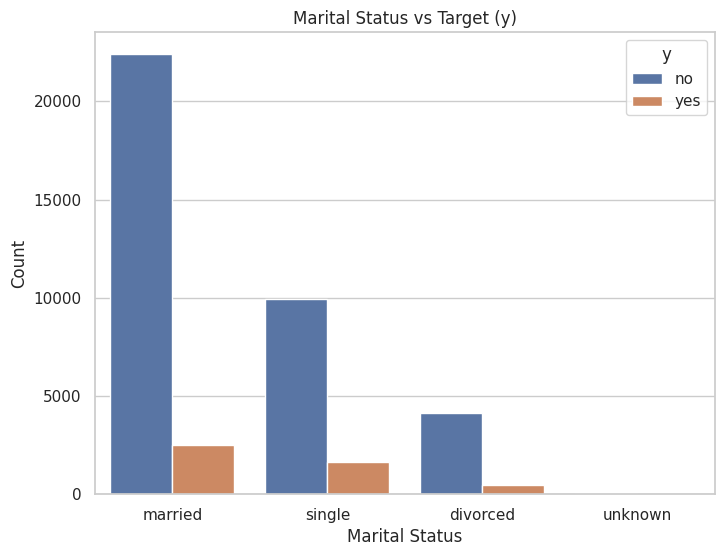

In [320]:



sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(x='marital', hue='y', data=total_data)


plt.title('Marital Status vs Target (y)')
plt.xlabel('Marital Status')
plt.ylabel('Count')


plt.show()

# Married individuals are less likely to need loans than single or divorced individuals, possibly due to greater financial stability from dual incomes.

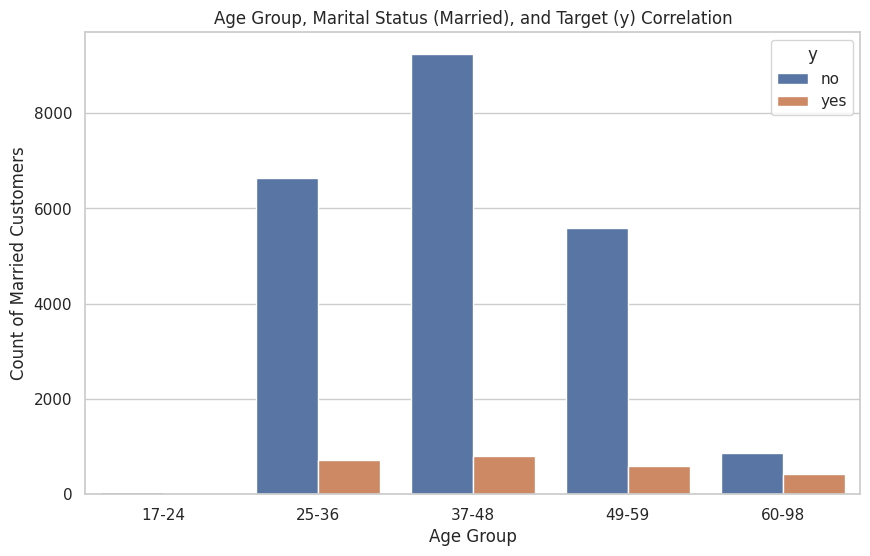

In [321]:


bins = [17, 24, 36, 48, 59, 98]
labels = ['17-24', '25-36', '37-48', '49-59', '60-98']


sns.set(style="whitegrid")


plt.figure(figsize=(10, 6))

# Corr between age and marital status (married) to the  target (y)
sns.countplot(x=pd.cut(total_data['age'], bins=bins, labels=labels, right=False), hue='y', data=total_data[total_data['marital'] == 'married'])


plt.title('Age Group, Marital Status (Married), and Target (y) Correlation')
plt.xlabel('Age Group')
plt.ylabel('Count of Married Customers')

plt.show()
 # Interested in seeing a general idea at around what age couples are more stable 

In [184]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [187]:
num_variables = ["age", "job", "marital", "education", "default", "loan", "housing", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

X = total_data.drop("y", axis = 1)[num_variables]
y = total_data["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.head()

,age,job,marital,education,default,loan,housing,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
12556,40,blue-collar,married,basic.9y,unknown,no,yes,93.918,-42.7,4.960,5228.1
35451,31,admin.,married,university.degree,no,no,no,92.893,-46.2,1.244,5099.1
30592,59,retired,married,basic.4y,no,no,no,92.893,-46.2,1.354,5099.1
17914,43,housemaid,divorced,basic.9y,no,no,yes,93.918,-42.7,4.961,5228.1
3315,39,admin.,single,high.school,unknown,no,no,93.994,-36.4,4.860,5191.0


In [29]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scal = scaler.transform(X_train)
X_train_scal = pd.DataFrame(X_train_scal, index = X_train.index, columns = num_variables)

X_test_scal = scaler.transform(X_test)
X_test_scal = pd.DataFrame(X_test_scal, index = X_test.index, columns = num_variables)

X_train_scal.head()

,age,job,marital,education,housing,default,loan,cons.conf.idx,cons.price.idx,euribor3m
12556,0.283951,0.272727,0.000000,0.428571,0.5,0.5,0.0,0.338912,0.669135,0.980730
35451,0.172840,0.181818,0.000000,0.857143,0.0,0.0,0.0,0.192469,0.269680,0.138291
30592,0.518519,0.454545,0.000000,0.000000,0.0,0.0,0.0,0.192469,0.269680,0.163228
17914,0.320988,0.000000,0.666667,0.428571,0.5,0.0,0.0,0.338912,0.669135,0.980957
3315,0.271605,0.181818,0.333333,0.142857,0.0,0.5,0.0,0.602510,0.698753,0.958059


In [30]:
from sklearn.feature_selection import f_classif, SelectKBest


selection_model = SelectKBest(f_classif, k = 5)
selection_model.fit(X_train_scal, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,job,default,cons.conf.idx,cons.price.idx,euribor3m
0,3.0,1.0,-42.7,93.918,4.960
1,2.0,0.0,-46.2,92.893,1.244
2,5.0,0.0,-46.2,92.893,1.354
3,0.0,0.0,-42.7,93.918,4.961
4,2.0,1.0,-36.4,93.994,4.860


In [31]:
X_test_sel.head()

,job,default,cons.conf.idx,cons.price.idx,euribor3m
0,4.0,0.0,-46.2,92.893,1.299
1,9.0,1.0,-36.4,93.994,4.860
2,3.0,0.0,-46.2,92.893,1.313
3,2.0,0.0,-41.8,94.465,4.967
4,0.0,0.0,-42.7,93.918,4.963


In [ ]:
new_total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv", sep = ";")


features = ["age", "job", "marital", "education", "housing", "default", "loan",
                 "cons.conf.idx", "cons.price.idx", "euribor3m"]
target = 'y'

X = new_total_data[features]
y = new_total_data[target]

    
    # Handle categorical variables (if necessary)
X = pd.get_dummies(X, drop_first=True)

    # Divide the sample into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

    # Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

    # Create and fit the model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

    # Check the model's performance
print("Training score:", model.score(X_train_scaled, y_train))
print("Testing score:", model.score(X_test_scaled, y_test))

Training score: 0.8892881421773332
Testing score: 0.8909391084781976


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test)

base_accuracy = accuracy_score(y_test, y_pred)
base_accuracy

/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.11197436146450422

In [27]:
# We define the parameters that we want to adjust by hand
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# We initialize the grid
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [29]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


In [30]:
grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}


In [36]:
model_grid = LogisticRegression(penalty = "l1", C = 10, solver = "liblinear")
model_grid.fit(X_train, y_train)


LogisticRegression(C=10, penalty='l1', solver='liblinear')

In [35]:
y_pred = model_grid.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8238,))

In [33]:
grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.8860160233066279